## Generate Sines

We identify three ways to generate sines with learnable patterns:


- Each dimension has a fixed frequency that never changes across samples : generate_sine_data_fixed()

- Each dimension has a fixed base frequency with a small uniform noise : generate_sine_data()

- Each dimension has its own probability distribution (normal distribution with specific mean and std) : generate_sine_data_with_embedding()


In [9]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.spectral_norm import spectral_norm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde
from scipy.linalg import sqrtm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


frequencies=[0.3, 0.6, 3.8, 1.2, 2.4]

def generate_sine_data_with_embedding(no=10000, seq_len=24, dim=5):
    """
    Generate sine dataset where frequencies are sampled from dimension-specific distributions.
    This creates a more structured latent space.
    """
    # Each dimension has its own frequency distribution
    freq_distributions = [
        {'mean': frequencies[0], 'std': 0.02},  # Dim 0: low frequency
        {'mean': frequencies[1], 'std': 0.02},  # Dim 1: medium-low
        {'mean': frequencies[2], 'std': 0.02},   # Dim 2: medium
        {'mean': frequencies[3], 'std': 0.02},  # Dim 3: medium-high
        {'mean': frequencies[4], 'std': 0.02},  # Dim 4: low-medium
    ]

    data = []
    for _ in range(no):
        sample = []
        for j in range(dim):
            freq = np.random.normal(freq_distributions[j]['mean'],
                                    freq_distributions[j]['std'])
            freq = max(0.1, min(5, freq))
            phase = np.random.uniform(0, 2*np.pi)
            feature_seq = [np.sin(freq*k + phase) for k in range(seq_len)]
            sample.append(feature_seq)

        data.append(np.array(sample).T)

    return torch.tensor(np.array(data), dtype=torch.float32)

def generate_sine_data_fixed(no=10000, seq_len=24, dim=5):
    """Generate sine dataset with completely fixed frequencies per dimension."""
    fixed_freqs = frequencies
    data = []
    for _ in range(no):
        sample = []
        for j in range(dim):
            freq = fixed_freqs[j]
            phase = np.random.uniform(0, 2*np.pi)
            feature_seq = [np.sin(freq*k + phase) for k in range(seq_len)]
            sample.append(feature_seq)
        data.append(np.array(sample).T)
    return torch.tensor(np.array(data), dtype=torch.float32)

def generate_sine_data_varied(no=10000, seq_len=24, dim=5):
    """Generate sine dataset with varied frequencies."""
    base_freqs = frequencies
    data = []
    for _ in range(no):
        sample = []
        for j in range(dim):
            freq = base_freqs[j] + np.random.uniform(-0.05, 0.05)
            freq = max(0.1, min(5, freq))
            phase = np.random.uniform(0, 2*np.pi)
            feature_seq = [np.sin(freq*k + phase) for k in range(seq_len)]
            sample.append(feature_seq)
        data.append(np.array(sample).T)
    return torch.tensor(np.array(data), dtype=torch.float32)

# Generate the data once for all algorithms
print("Generating dataset...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA = generate_sine_data_with_embedding(no=10000, seq_len=24, dim=5)
print(f"Data shape: {DATA.shape}")


Generating dataset...
Data shape: torch.Size([10000, 24, 5])


### Visualization

In [10]:

# ============================================
# Visualization Functions
# ============================================
def plot_detailed_comparison(original, vae_recon, ldm_gen, algorithm_name="Algorithm", num_samples=3):
    """Plot detailed comparison showing all dimensions"""
    original = original.cpu()
    vae_recon = vae_recon.detach().cpu() if hasattr(vae_recon, 'detach') else torch.tensor(vae_recon).cpu()
    ldm_gen = ldm_gen.cpu() if hasattr(ldm_gen, 'cpu') else torch.tensor(ldm_gen).cpu()

    dim = original.shape[2]
    fig, axes = plt.subplots(num_samples, dim, figsize=(4*dim, 3*num_samples))
    fig.suptitle(f'{algorithm_name} - Time Series Comparison', fontsize=16, y=1.02)

    for i in range(num_samples):
        for d in range(dim):
            axes[i, d].plot(original[i, :, d].numpy(), 'b-', linewidth=2, alpha=0.8, label='Original')
            axes[i, d].plot(vae_recon[i, :, d].numpy(), 'g--', linewidth=2, alpha=0.8, label='VAE Recon')
            axes[i, d].plot(ldm_gen[i, :, d].numpy(), 'r:', linewidth=2, alpha=0.8, label='Generated')

            axes[i, d].set_title(f'Sample {i+1}, Dim {d+1}')
            axes[i, d].set_ylim(-1.5, 1.5)
            axes[i, d].grid(True, alpha=0.3)
            if i == 0 and d == 0:
                axes[i, d].legend()

    plt.tight_layout()
    plt.show()

def plot_frequency_analysis(original, vae_recon, ldm_gen, algorithm_name="Algorithm", num_samples=3):
    """Plot FFT magnitude to compare frequency preservation"""
    original = original.cpu()
    vae_recon = vae_recon.detach().cpu() if hasattr(vae_recon, 'detach') else torch.tensor(vae_recon).cpu()
    ldm_gen = ldm_gen.cpu() if hasattr(ldm_gen, 'cpu') else torch.tensor(ldm_gen).cpu()

    dim = original.shape[2]
    fig, axes = plt.subplots(num_samples, dim, figsize=(4*dim, 3*num_samples))
    fig.suptitle(f'{algorithm_name} - Frequency Analysis (FFT Magnitude)', fontsize=16, y=1.02)

    for i in range(num_samples):
        for d in range(dim):
            fft_orig = torch.fft.rfft(original[i, :, d]).abs().numpy()
            fft_vae = torch.fft.rfft(vae_recon[i, :, d]).abs().numpy()
            fft_ldm = torch.fft.rfft(ldm_gen[i, :, d]).abs().numpy()

            freq_bins = np.arange(len(fft_orig))

            axes[i, d].plot(freq_bins, fft_orig, 'b-', linewidth=2, alpha=0.8, label='Original')
            axes[i, d].plot(freq_bins, fft_vae, 'g--', linewidth=2, alpha=0.8, label='VAE Recon')
            axes[i, d].plot(freq_bins, fft_ldm, 'r:', linewidth=2, alpha=0.8, label='Generated')

            axes[i, d].set_title(f'Sample {i+1}, Dim {d+1}')
            axes[i, d].grid(True, alpha=0.3)
            if i == 0 and d == 0:
                axes[i, d].legend()

    plt.tight_layout()
    plt.show()

def plot_tsne_comparison(real, synth, algorithm_name="Algorithm"):
    """Plot t-SNE visualization comparing real and synthetic data"""
    real = real.cpu().numpy() if hasattr(real, 'cpu') else np.array(real)
    synth = synth.cpu().numpy() if hasattr(synth, 'cpu') else np.array(synth)

    # Take subset if too large
    n_samples = min(500, len(real), len(synth))
    real_subset = real[:n_samples].reshape(n_samples, -1)
    synth_subset = synth[:n_samples].reshape(n_samples, -1)

    combined = np.vstack([real_subset, synth_subset])
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    combined_tsne = tsne.fit_transform(combined)

    plt.figure(figsize=(8, 6))
    plt.scatter(combined_tsne[:n_samples, 0], combined_tsne[:n_samples, 1],
                alpha=0.6, s=10, c='blue', label='Original')
    plt.scatter(combined_tsne[n_samples:, 0], combined_tsne[n_samples:, 1],
                alpha=0.6, s=10, c='red', label='Generated')
    plt.title(f'{algorithm_name} - t-SNE Distribution Comparison')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_kde_comparison(real, synth, algorithm_name="Algorithm"):
    """Plot KDE comparison for the first feature"""
    real = real.cpu().numpy() if hasattr(real, 'cpu') else np.array(real)
    synth = synth.cpu().numpy() if hasattr(synth, 'cpu') else np.array(synth)

    plt.figure(figsize=(8, 6))
    x_range = np.linspace(-1.5, 1.5, 200)

    kde_real = gaussian_kde(real[:, :, 0].flatten())
    kde_synth = gaussian_kde(synth[:, :, 0].flatten())

    plt.plot(x_range, kde_real(x_range), 'b-', linewidth=2, label='Original')
    plt.plot(x_range, kde_synth(x_range), 'r--', linewidth=2, label='Generated')
    plt.title(f'{algorithm_name} - KDE Comparison (Feature 1)')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_dimension_statistics(data, title="Dimension Statistics", algorithm_name=""):
    """Plot frequency distributions per dimension"""
    data = data.cpu().numpy() if hasattr(data, 'cpu') else np.array(data)
    dim = data.shape[2]
    fig, axes = plt.subplots(1, dim, figsize=(4*dim, 4))
    fig.suptitle(f'{algorithm_name} - {title}', fontsize=14)

    for d in range(dim):
        freqs = []
        for i in range(min(100, len(data))):
            fft_vals = np.abs(np.fft.rfft(data[i, :, d]))
            peak_freq = np.argmax(fft_vals)
            freqs.append(peak_freq)

        axes[d].hist(freqs, bins=10, alpha=0.7, color='blue' if 'Original' in title else 'red')
        axes[d].set_title(f'Dim {d+1} Frequency Distribution')
        axes[d].set_xlabel('Peak Frequency Bin')
        axes[d].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# ============================================
# Evaluation Functions
# ============================================
def compute_context_fid_score(real, synth):
    """Context-FID score using statistical features"""
    def extract_features(data):
        data = data.cpu() if hasattr(data, 'cpu') else torch.tensor(data)
        batch_size = len(data)
        features = []

        for i in range(batch_size):
            sample = data[i]
            mean = sample.mean(dim=0)
            std = sample.std(dim=0)
            skew = ((sample - mean) ** 3).mean(dim=0) / (std ** 3 + 1e-8)
            kurt = ((sample - mean) ** 4).mean(dim=0) / (std ** 4 + 1e-8)
            min_val = sample.min(dim=0)[0]
            max_val = sample.max(dim=0)[0]
            range_val = max_val - min_val

            autocorr = []
            for lag in range(1, 4):
                if lag < len(sample):
                    ac = (sample[lag:] * sample[:-lag]).mean(dim=0)
                    autocorr.append(ac)

            fft_vals = torch.fft.rfft(sample, dim=0)
            fft_magnitudes = fft_vals.abs()
            dominant_freqs = fft_magnitudes.topk(3, dim=0)[0].mean(dim=0)

            feature = torch.cat([
                mean, std, skew, kurt,
                min_val, max_val, range_val,
                *autocorr,
                dominant_freqs
            ])
            features.append(feature)

        return torch.stack(features)

    real_feat = extract_features(real)
    synth_feat = extract_features(synth)

    mu_real = real_feat.mean(dim=0)
    mu_synth = synth_feat.mean(dim=0)

    real_feat_centered = real_feat - mu_real
    synth_feat_centered = synth_feat - mu_synth

    cov_real = (real_feat_centered.T @ real_feat_centered) / (len(real_feat) - 1)
    cov_synth = (synth_feat_centered.T @ synth_feat_centered) / (len(synth_feat) - 1)

    eps = 1e-6
    cov_real += eps * torch.eye(cov_real.size(0))
    cov_synth += eps * torch.eye(cov_synth.size(0))

    mu_real_np = mu_real.numpy()
    mu_synth_np = mu_synth.numpy()
    cov_real_np = cov_real.numpy()
    cov_synth_np = cov_synth.numpy()

    diff = mu_real_np - mu_synth_np
    diff_norm = np.dot(diff, diff)

    cov_prod = cov_real_np @ cov_synth_np
    cov_prod_sqrt = sqrtm(cov_prod)
    cov_prod_sqrt = np.real(cov_prod_sqrt)

    trace_term = np.trace(cov_real_np + cov_synth_np - 2 * cov_prod_sqrt)

    fid = diff_norm + trace_term
    return fid

def compute_correlational_score(real, synth):
    """Correlational score"""
    def compute_cross_correlation(data):
        data = data.cpu() if hasattr(data, 'cpu') else torch.tensor(data)
        batch_size, seq_len, dim = data.shape
        corr_mats = []
        for i in range(min(batch_size, 500)):
            sample = data[i]
            sample_normalized = (sample - sample.mean(dim=0)) / (sample.std(dim=0) + 1e-8)
            corr = torch.corrcoef(sample_normalized.T)
            corr_mats.append(corr)
        return torch.stack(corr_mats).mean(dim=0)

    real_corr = compute_cross_correlation(real)
    synth_corr = compute_cross_correlation(synth)
    return torch.abs(real_corr - synth_corr).mean().item()

def compute_discriminative_score(real, synth, seq_len, input_dim, epochs=200):
    """Discriminative score"""
    class Discriminator(nn.Module):
        def __init__(self, input_dim, hidden_dim=100):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2)
            self.linear = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            return self.sigmoid(self.linear(out))

    real = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)
    synth = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)

    X = torch.cat([real, synth], dim=0)
    y = torch.cat([torch.ones(len(real)), torch.zeros(len(synth))], dim=0)

    idx = torch.randperm(len(X))
    X, y = X[idx], y[idx]

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Discriminator(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        pred = model(X_train).squeeze()
        loss = F.binary_cross_entropy(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(X_test).squeeze()
        accuracy = ((pred > 0.5).float() == y_test).float().mean()

    return 1 - accuracy.item()

def compute_predictive_score(real, synth, seq_len, input_dim, pred_len=5, epochs=100):
    """Predictive score using TSTR"""
    class Predictor(nn.Module):
        def __init__(self, input_dim, hidden_dim=100):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=2)
            self.linear = nn.Linear(hidden_dim, input_dim)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.linear(out[:, -pred_len:, :])

    synth = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)
    real = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)

    X_synth = synth[:, :-pred_len, :]
    y_synth = synth[:, -pred_len:, :]
    X_real = real[:, :-pred_len, :]
    y_real = real[:, -pred_len:, :]

    predictor = Predictor(input_dim)
    optimizer = optim.Adam(predictor.parameters(), lr=1e-3)

    for epoch in range(epochs):
        predictor.train()
        pred = predictor(X_synth)
        loss = F.mse_loss(pred, y_synth)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictor.eval()
    with torch.no_grad():
        pred = predictor(X_real)
        mse = F.mse_loss(pred, y_real)

    return mse.item()

def evaluate_all_metrics(real, synth, seq_len, input_dim, algorithm_name="Algorithm"):
    """Compute all evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"{algorithm_name} - Evaluation Metrics")
    print('='*50)

    real_cpu = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)
    synth_cpu = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)

    n_samples = min(1000, len(real_cpu), len(synth_cpu))
    real_subset = real_cpu[:n_samples]
    synth_subset = synth_cpu[:n_samples]

    # FID Score
    fid = compute_context_fid_score(real_subset, synth_subset)
    print(f"Context-FID Score: {fid:.4f}")

    # Correlational Score
    corr = compute_correlational_score(real_subset, synth_subset)
    print(f"Correlational Score: {corr:.4f}")

    # Discriminative Score
    disc = compute_discriminative_score(real_subset, synth_subset, seq_len, input_dim)
    print(f"Discriminative Score: {disc:.4f}")

    # Predictive Score
    pred = compute_predictive_score(real_subset, synth_subset, seq_len, input_dim)
    print(f"Predictive Score: {pred:.4f}")

    return {
        'fid': fid,
        'correlational': corr,
        'discriminative': disc,
        'predictive': pred
    }

print("Visualization and evaluation functions loaded successfully!")

Visualization and evaluation functions loaded successfully!


## First Algorithm


RUNNING ALGORITHM 1: Original Transformer VAE + LDM

Step 1: Training VAE...


Algorithm 1: Training VAE: 100%|██████████| 30/30 [00:21<00:00,  1.41it/s]



Step 2: Training LDM...


Algorithm 1: Training LDM: 100%|██████████| 30/30 [00:03<00:00,  7.87it/s]



Step 3: Generating samples...

ALGORITHM 1: Visualization and Evaluation


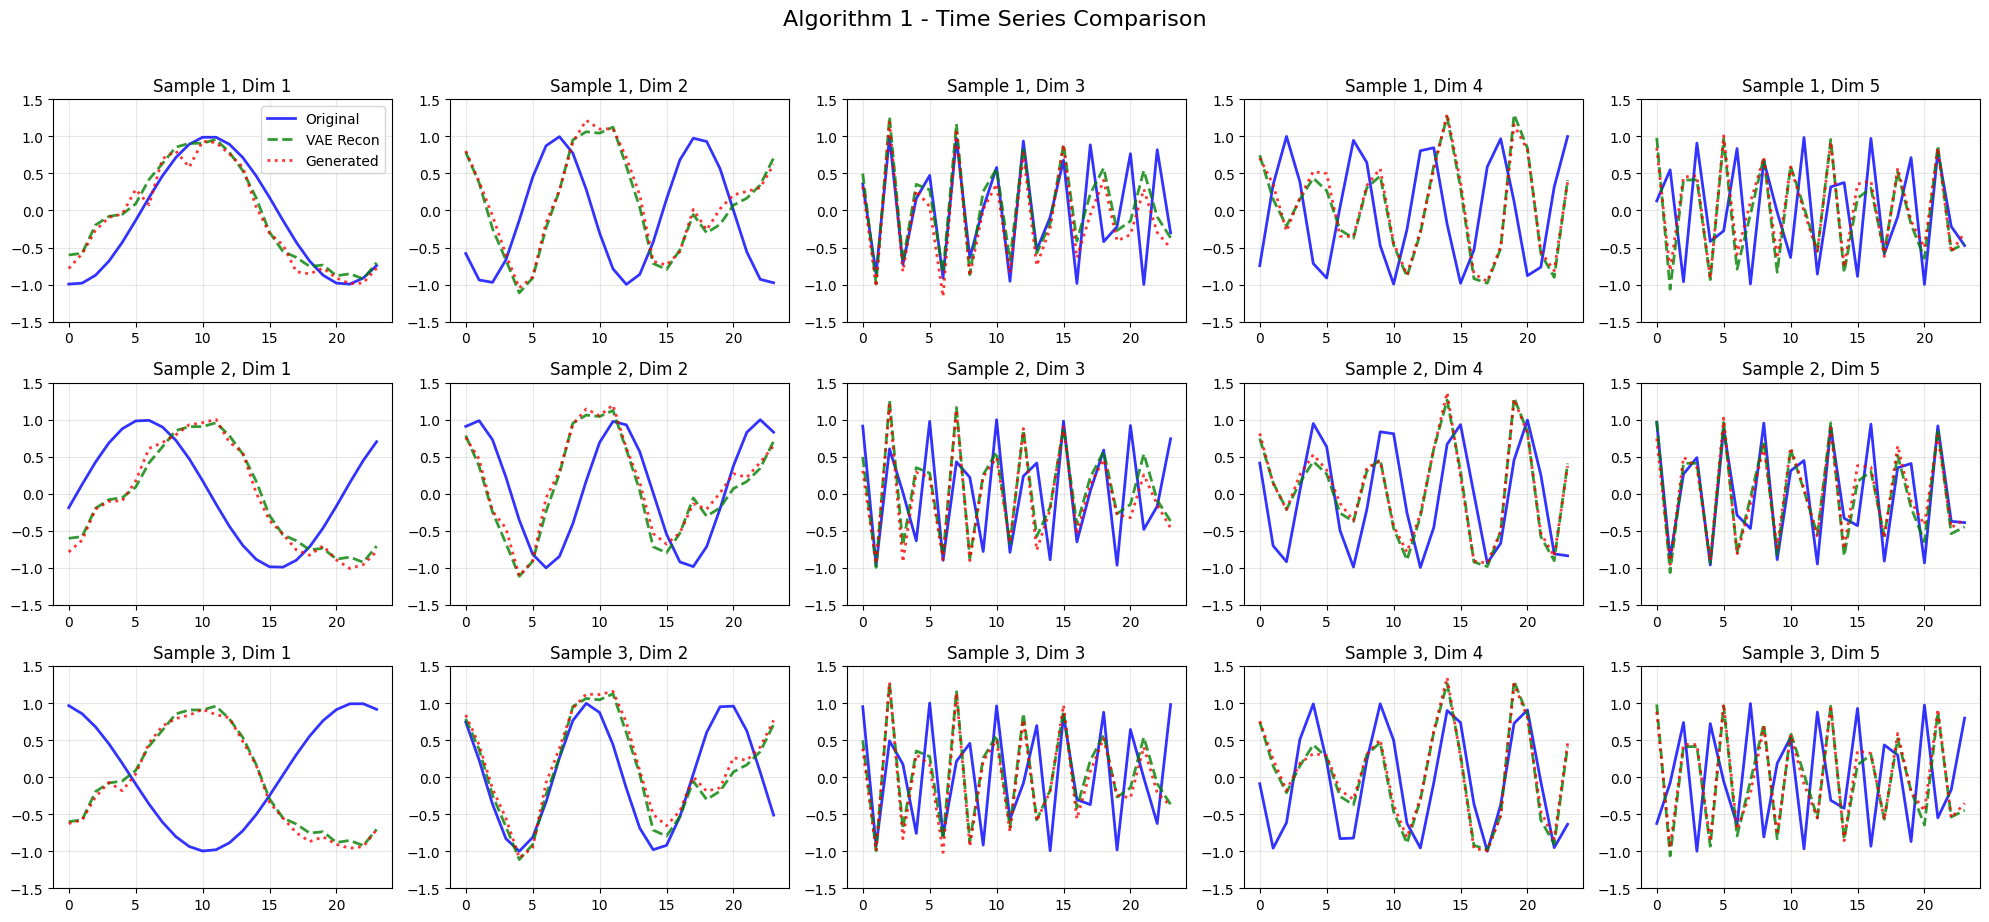

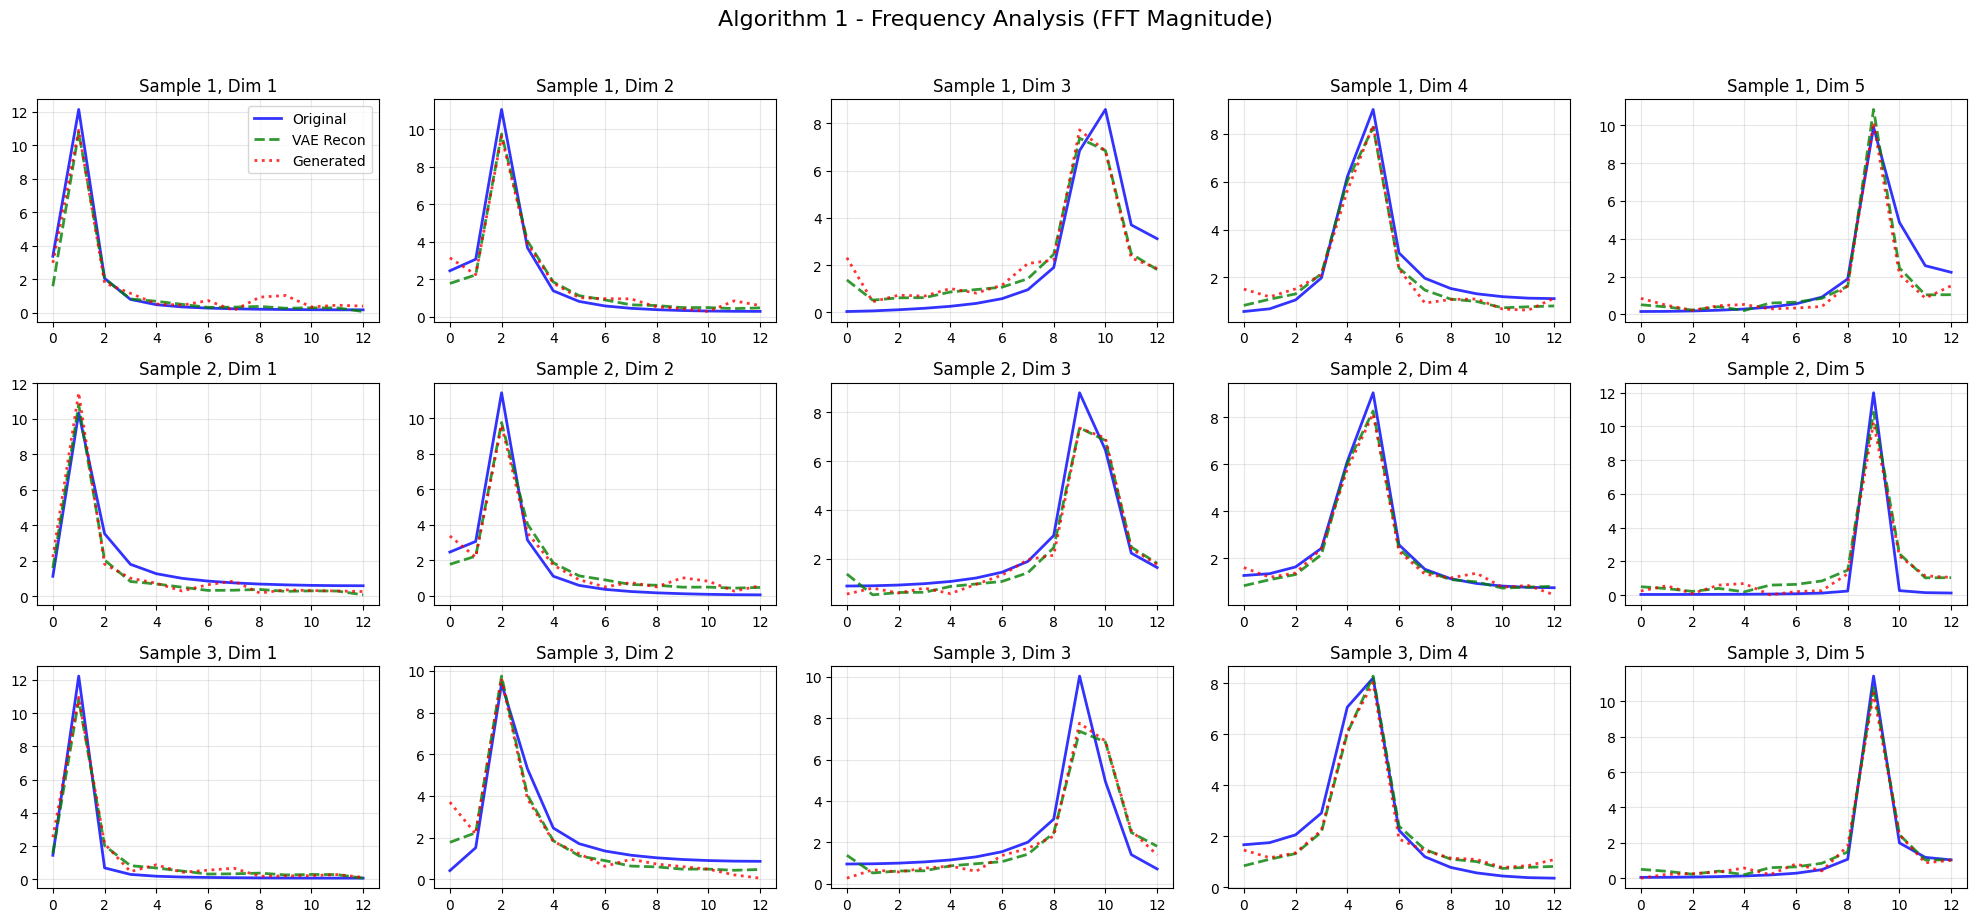

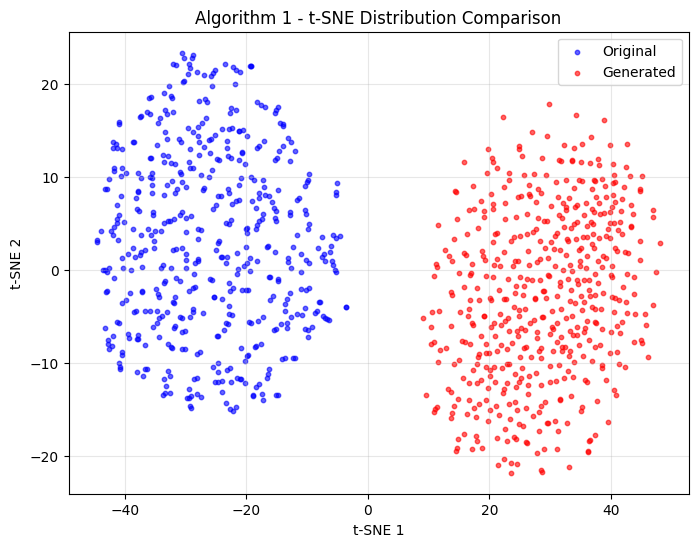

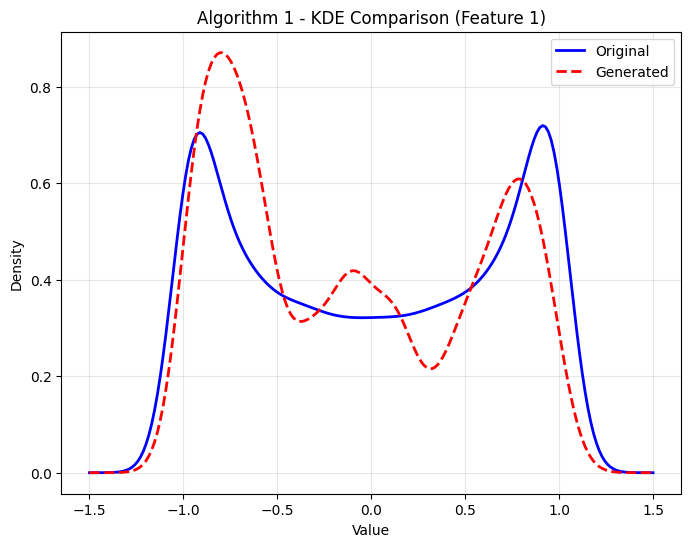

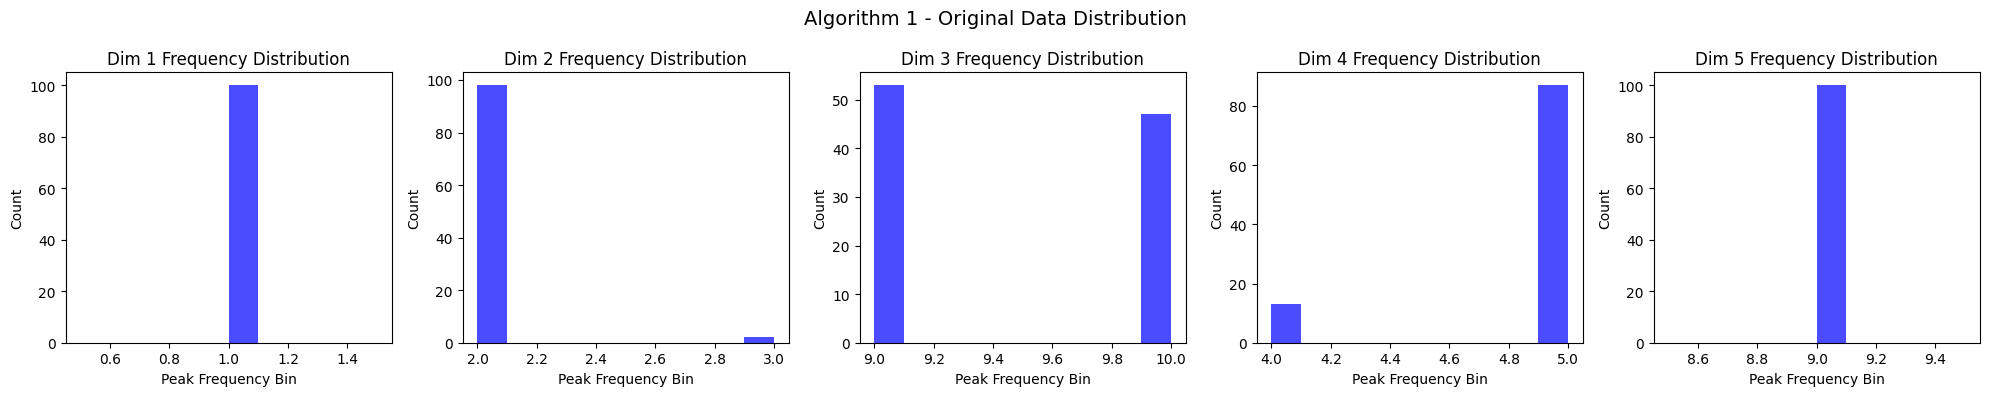

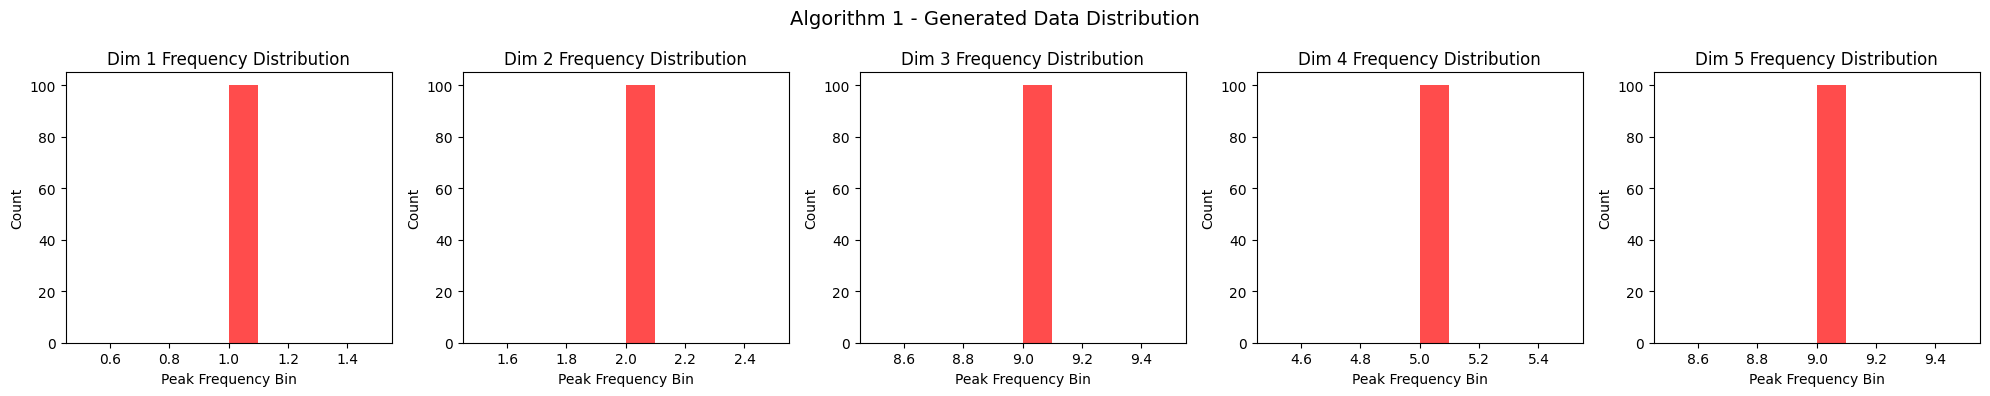


Algorithm 1 - Evaluation Metrics
Context-FID Score: 2.6034
Correlational Score: 0.0817
Discriminative Score: 0.0000
Predictive Score: 0.8418

Algorithm 1 completed successfully!


In [11]:

# ============================================
# Algorithm 1: Original Transformer VAE and LDM
# ============================================
class Algorithm1_TransformerVAE(nn.Module):
    def __init__(self, input_dim=5, latent_dim=16, n_heads=2, seq_len=24, layers=(1,2)):
        super().__init__()
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.input_dim = input_dim

        # Encoder
        self.embed = nn.Sequential(
            nn.Conv1d(input_dim, latent_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(latent_dim, latent_dim, 3, padding=1)
        )
        self.pos_enc = nn.Parameter(torch.randn(1, seq_len, latent_dim))
        enc_layer = nn.TransformerEncoderLayer(d_model=latent_dim, nhead=n_heads, batch_first=True, dropout=0.0)
        self.encoder_mu = nn.TransformerEncoder(enc_layer, num_layers=layers[0])
        self.encoder_log_var = nn.TransformerEncoder(enc_layer, num_layers=layers[0])

        # Decoder
        self.dec_embed = nn.Sequential(
            nn.Conv1d(latent_dim, latent_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(latent_dim, latent_dim, 3, padding=1)
        )
        self.dec_pos_enc = nn.Parameter(torch.randn(1, seq_len, latent_dim))
        dec_layer = nn.TransformerDecoderLayer(d_model=latent_dim, nhead=n_heads, batch_first=True, dropout=0.0)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=layers[1])
        self.output_proj = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        e = self.embed(x.permute(0,2,1)).permute(0,2,1)
        e_pe = e + self.pos_enc
        mu = self.encoder_mu(e_pe)
        log_var = self.encoder_log_var(e_pe)
        log_var = torch.clamp(log_var, min=-10, max=10)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        sigma = torch.exp(0.5*log_var)
        eps = torch.randn_like(sigma)
        return mu + eps*sigma

    def decode(self, z):
        z_emb = self.dec_embed(z.permute(0,2,1)).permute(0,2,1)
        z_pe = z_emb + self.dec_pos_enc
        recon = self.decoder(z_pe, z)
        return self.output_proj(recon)

class Algorithm1_LatentDiffusion(nn.Module):
    def __init__(self, latent_dim=16, seq_len=24, hidden_dim=1024):
        super().__init__()
        self.latent_dim = latent_dim
        self.seq_len = seq_len

        self.input_proj = nn.Linear(latent_dim*seq_len, hidden_dim)

        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim*seq_len)
        )

    def sinusoidal_embedding(self, t, dim):
        half = dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device).float() * (np.log(10000)/(half-1)))
        args = t[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, z_t, t):
        batch_size = z_t.size(0)
        z_flat = z_t.reshape(batch_size, -1)
        z_proj = self.input_proj(z_flat)
        t_emb = self.sinusoidal_embedding(t, z_proj.shape[1])
        t_proj = self.time_embed(t_emb)
        h = z_proj + t_proj
        out = self.net(h)
        return out.reshape(batch_size, self.seq_len, self.latent_dim)

def train_algorithm1_vae(model, data, epochs=50, batch_size=1024, beta_max=1.0):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    beta = 0.0
    beta_inc = beta_max/epochs

    for epoch in tqdm(range(epochs), desc="Algorithm 1: Training VAE"):
        model.train()
        perm = torch.randperm(len(data))

        for i in range(0, len(data), batch_size):
            idx = perm[i:i+batch_size]
            x = data[idx].to(device)

            mu, log_var = model.encode(x)
            z = model.reparameterize(mu, log_var)
            recon_x = model.decode(z)

            dim = x.shape[2]
            l2_loss_dim = 0
            l1_loss_dim = 0
            fft_loss_dim = 0

            for d in range(dim):
                x_d = x[:, :, d]
                recon_d = recon_x[:, :, d]

                l2_loss_dim += F.mse_loss(recon_d, x_d)
                l1_loss_dim += F.l1_loss(recon_d, x_d)

                fft_x = torch.fft.rfft(x_d, dim=1)
                fft_recon = torch.fft.rfft(recon_d, dim=1)
                fft_loss_dim += F.mse_loss(fft_x.abs(), fft_recon.abs())

            l2_loss = l2_loss_dim / dim
            l1_loss = l1_loss_dim / dim
            fft_loss = fft_loss_dim / dim

            recon_loss = l1_loss + l2_loss + fft_loss
            kl_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=(-1, -2)))

            loss = recon_loss + beta * kl_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        beta = min(beta + beta_inc, beta_max)

    return model

def train_algorithm1_ldm(ldm_model, vae_model, data, epochs=50, batch_size=1024, T=1.0):
    optimizer = optim.Adam(ldm_model.parameters(), lr=1e-4)
    vae_model.eval()

    with torch.no_grad():
        mu_list = []
        for i in range(0, len(data), batch_size):
            x_batch = data[i:i+batch_size].to(device)
            mu, _ = vae_model.encode(x_batch)
            mu_list.append(mu.cpu())
        mu_all = torch.cat(mu_list, dim=0)

    for epoch in tqdm(range(epochs), desc="Algorithm 1: Training LDM"):
        perm = torch.randperm(len(mu_all))

        for i in range(0, len(mu_all), batch_size):
            idx = perm[i:i+batch_size]
            z0 = mu_all[idx].to(device)

            t = torch.rand(z0.size(0), device=z0.device) * T
            epsilon = torch.randn_like(z0)
            zt = z0 + t[:, None, None] * epsilon

            pred_eps = ldm_model(zt, t)
            loss = F.mse_loss(pred_eps, epsilon)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ldm_model.parameters(), 1.0)
            optimizer.step()

    return ldm_model

@torch.no_grad()
def sample_algorithm1_ldm(ldm_model, vae_model, num_samples, seq_len, latent_dim, device, T=1.0, steps=100):
    ldm_model.eval()
    vae_model.eval()

    zt = torch.randn(num_samples, seq_len, latent_dim, device=device) * T
    dt = T / steps

    for i in range(steps, 0, -1):
        t_val = i * dt
        t_tensor = torch.full((num_samples,), t_val, device=device)

        epsilon_pred = ldm_model(zt, t_tensor)
        score = -epsilon_pred / t_val

        zt = zt + 2 * t_val * score * dt

        if i > 1:
            noise = torch.randn_like(zt) * torch.sqrt(torch.tensor(2 * t_val * dt, device=device))
            zt = zt + noise

    samples = vae_model.decode(zt)
    return samples

# ============================================
# Run Algorithm 1
# ============================================
print("\n" + "="*60)
print("RUNNING ALGORITHM 1: Original Transformer VAE + LDM")
print("="*60)

# Parameters
seq_len = 24
input_dim = 5
latent_dim = 16

# Move data to device
data_algo1 = DATA.to(device)

# Train VAE
print("\nStep 1: Training VAE...")
vae_algo1 = Algorithm1_TransformerVAE(
    input_dim=input_dim,
    latent_dim=latent_dim,
    seq_len=seq_len,
    layers=(1, 2)
).to(device)

vae_algo1 = train_algorithm1_vae(vae_algo1, data_algo1, epochs=30, batch_size=1024, beta_max=1.0)

# Get VAE reconstructions
with torch.no_grad():
    vae_algo1.eval()
    test_data_algo1 = data_algo1[:100]
    mu_test, _ = vae_algo1.encode(test_data_algo1)
    vae_recon_algo1 = vae_algo1.decode(mu_test)

# Train LDM
print("\nStep 2: Training LDM...")
ldm_algo1 = Algorithm1_LatentDiffusion(
    latent_dim=latent_dim,
    seq_len=seq_len,
    hidden_dim=1024
).to(device)

ldm_algo1 = train_algorithm1_ldm(ldm_algo1, vae_algo1, data_algo1, epochs=30, batch_size=1024)

# Generate samples
print("\nStep 3: Generating samples...")
num_samples = 1000
synth_algo1 = sample_algorithm1_ldm(
    ldm_algo1, vae_algo1, num_samples, seq_len, latent_dim, device,
    T=1.0, steps=100
)

# ============================================
# Visualize and Evaluate Algorithm 1
# ============================================
print("\n" + "="*60)
print("ALGORITHM 1: Visualization and Evaluation")
print("="*60)

# Move to CPU for visualization
test_data_cpu = test_data_algo1.cpu()
vae_recon_cpu = vae_recon_algo1.cpu()
synth_algo1_cpu = synth_algo1.cpu()
data_cpu = data_algo1.cpu()

# 1. Time Series Comparison
plot_detailed_comparison(test_data_cpu, vae_recon_cpu, synth_algo1_cpu[:100],
                         algorithm_name="Algorithm 1", num_samples=3)

# 2. Frequency Analysis
plot_frequency_analysis(test_data_cpu, vae_recon_cpu, synth_algo1_cpu[:100],
                        algorithm_name="Algorithm 1", num_samples=3)

# 3. t-SNE Comparison
plot_tsne_comparison(data_cpu[:500], synth_algo1_cpu[:500], algorithm_name="Algorithm 1")

# 4. KDE Comparison
plot_kde_comparison(data_cpu[:500], synth_algo1_cpu[:500], algorithm_name="Algorithm 1")

# 5. Dimension Statistics
plot_dimension_statistics(data_cpu, title="Original Data Distribution", algorithm_name="Algorithm 1")
plot_dimension_statistics(synth_algo1_cpu, title="Generated Data Distribution", algorithm_name="Algorithm 1")

# 6. Evaluation Metrics
metrics_algo1 = evaluate_all_metrics(data_cpu, synth_algo1_cpu, seq_len, input_dim, "Algorithm 1")

print("\nAlgorithm 1 completed successfully!")

# Second algorithm (good VAE)


RUNNING ALGORITHM 3: Enhanced TimeLDM with Spectral Norm and Residual Blocks

Step 1: Training Enhanced VAE...


Algorithm 3: VAE Training: 100%|██████████| 30/30 [00:14<00:00,  2.10it/s]



Step 2: Extracting latents for LDM...

Step 3: Training Enhanced LDM...


Algorithm 3: LDM Training: 100%|██████████| 30/30 [00:03<00:00,  8.69it/s]



Step 4: Generating samples...

ALGORITHM 3: Visualization and Evaluation


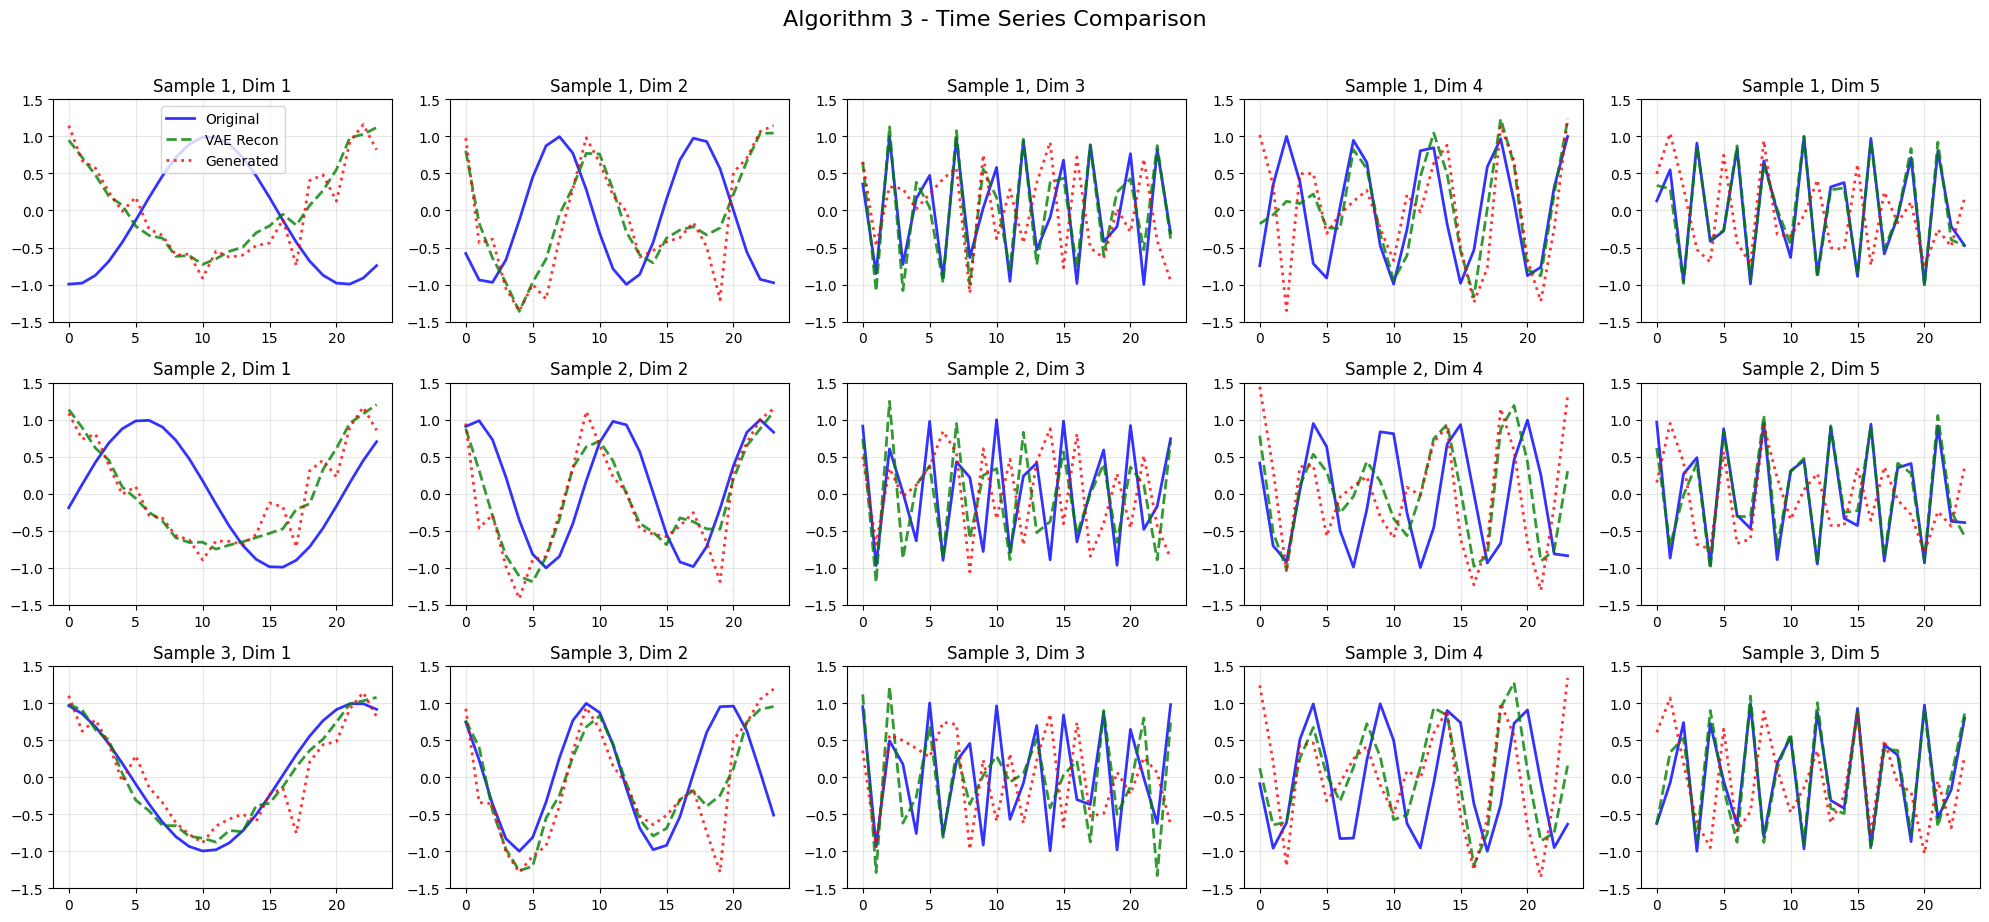

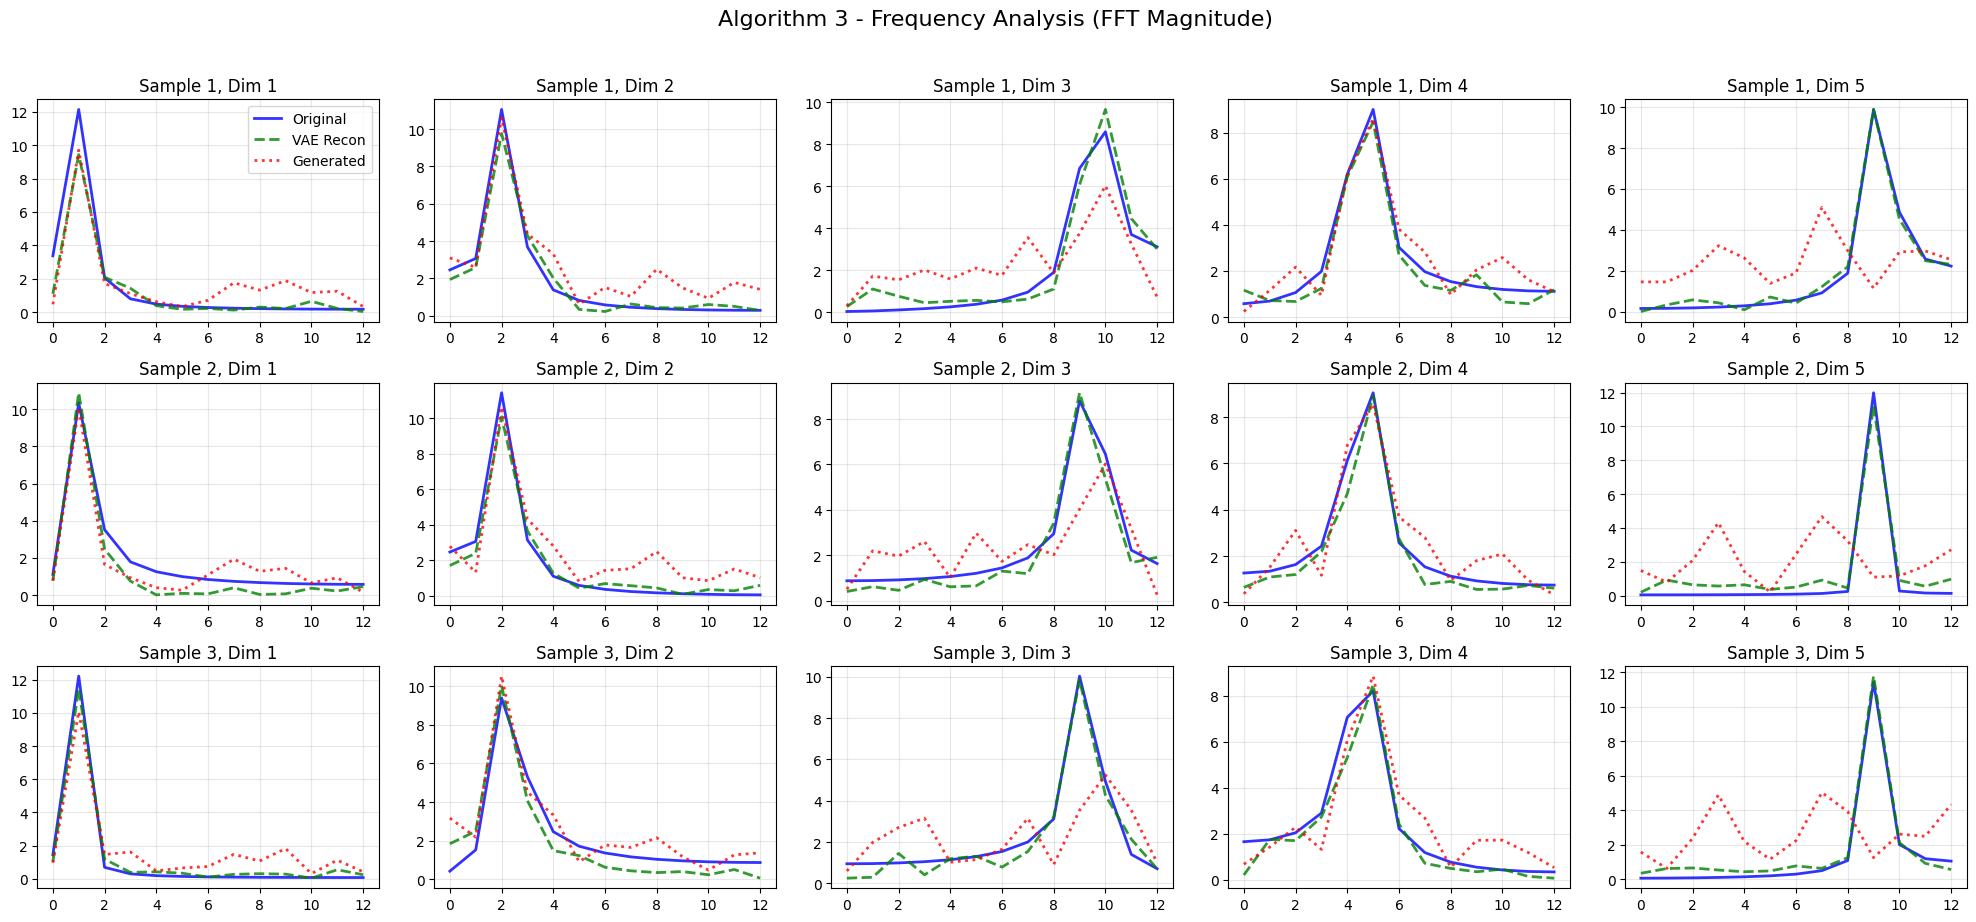

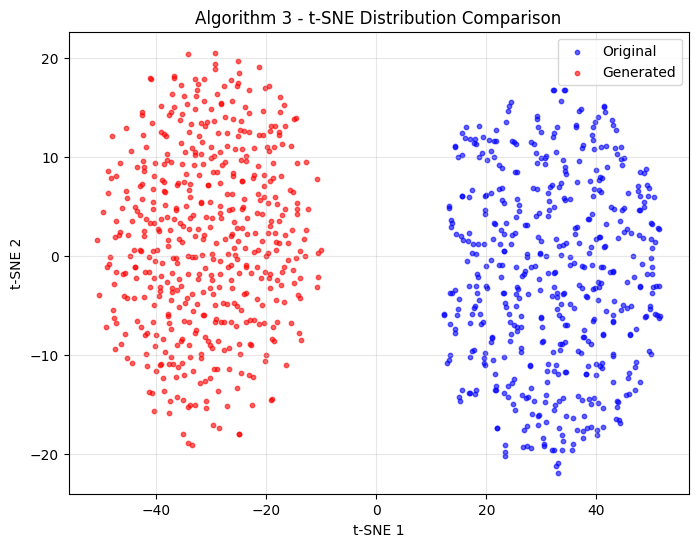

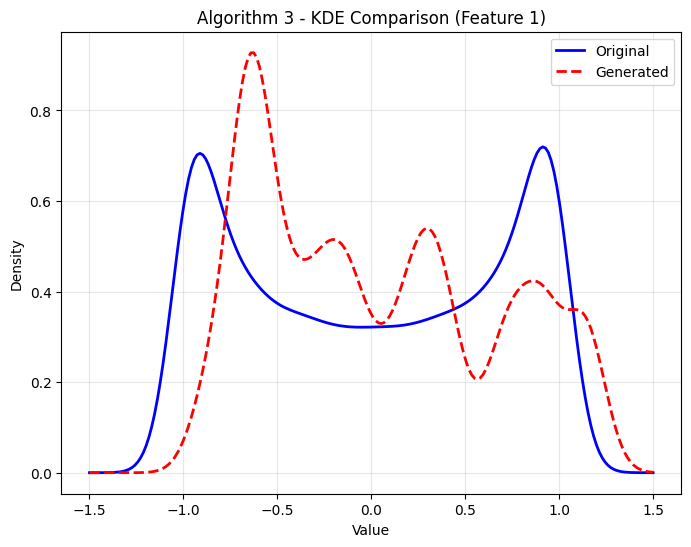

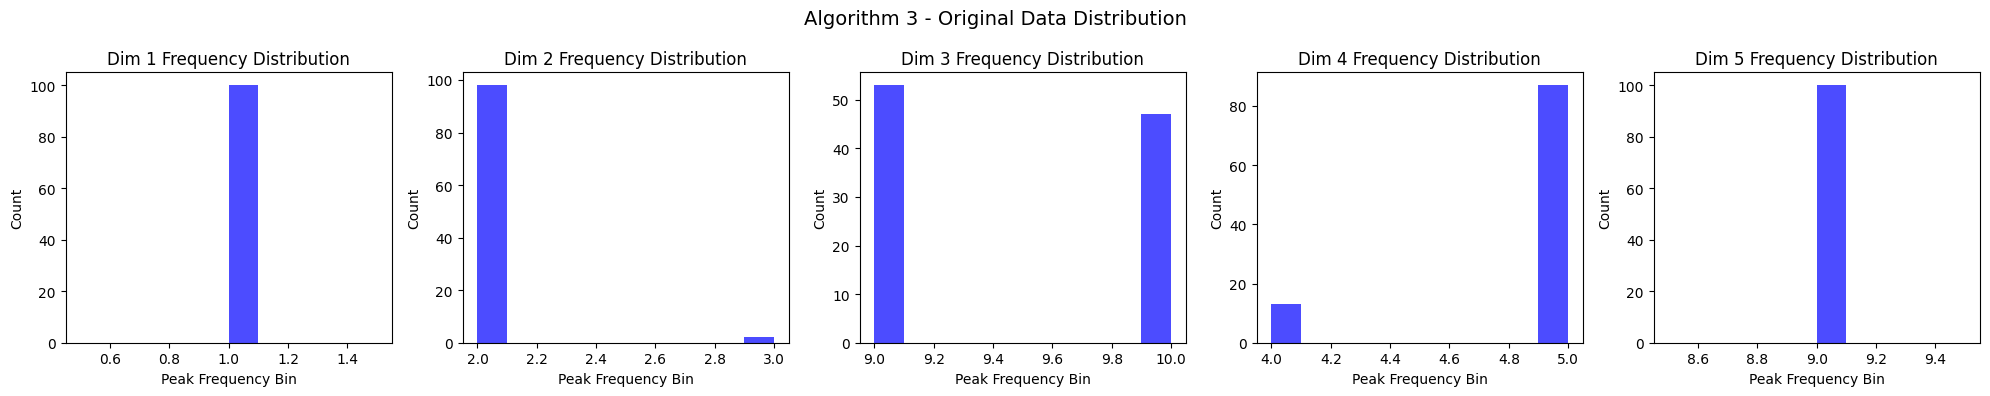

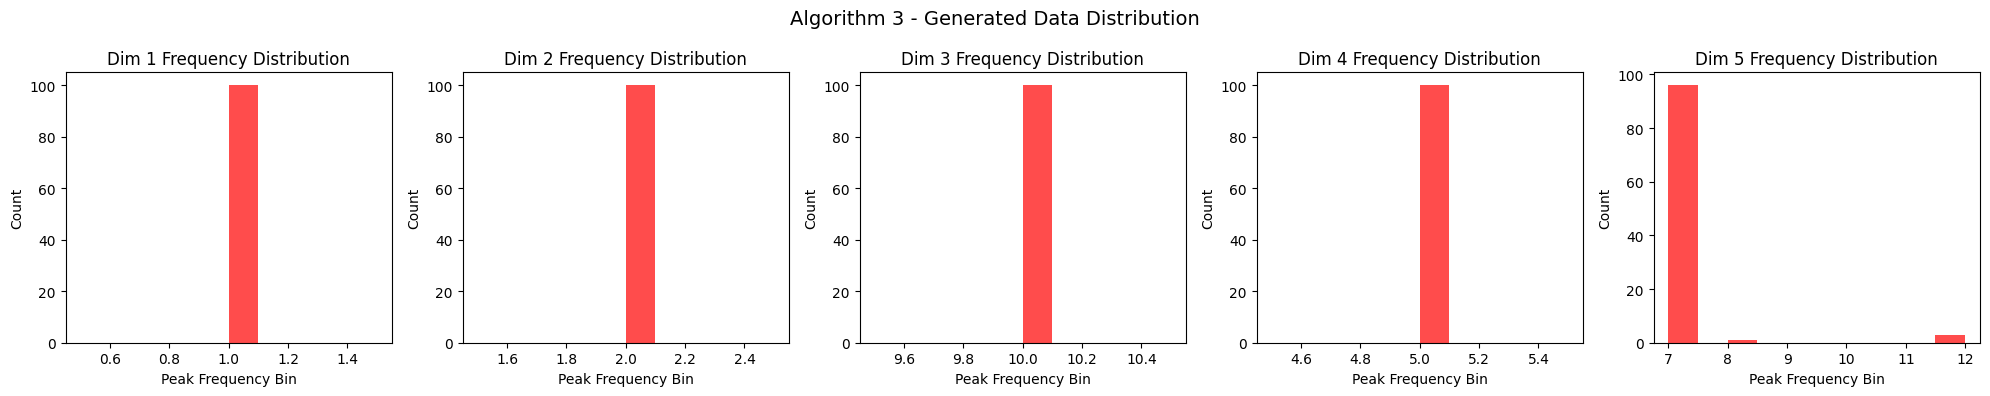


Algorithm 3 - Evaluation Metrics
Context-FID Score: 7.5311
Correlational Score: 0.1043
Discriminative Score: 0.0000
Predictive Score: 1.0757

FINAL COMPARISON OF ALL THREE ALGORITHMS
Context-FID          2.6034           7.5311         
Correlational        0.0817          0.1043         
Discriminative       0.0000          0.0000         
Predictive           0.8418           1.0757         

All three algorithms completed successfully!
Algorithm 1: Original Transformer VAE + LDM
Algorithm 3: Enhanced TimeLDM with Spectral Norm and Residual Blocks


In [12]:


# ============================================
# Algorithm 2: Enhanced TimeLDM with Spectral Norm and Residual Blocks
# ============================================

class PositionalEncoding(nn.Module):
    """Learnable positional encoding"""
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class Algorithm3_VAEEncoder(nn.Module):
    """VAE Encoder with spectral normalization"""
    def __init__(self, input_dim: int, latent_dim: int, num_heads: int = 2,
                 num_layers: int = 2, seq_len: int = 24):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        self.embedding_cnn = nn.Sequential(
            spectral_norm(nn.Conv1d(input_dim, latent_dim, kernel_size=3, padding=1)),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            spectral_norm(nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1)),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
        )

        self.pos_encoding = PositionalEncoding(latent_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=latent_dim * 4,
            dropout=0.1,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mean_head = spectral_norm(nn.Linear(latent_dim, latent_dim))
        self.logvar_head = spectral_norm(nn.Linear(latent_dim, latent_dim))
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, x):
        x_permuted = x.permute(0, 2, 1)
        embedded = self.embedding_cnn(x_permuted)
        embedded = embedded.permute(0, 2, 1)
        embedded = self.norm(embedded)
        embedded_pe = self.pos_encoding(embedded)
        transformed = self.transformer(embedded_pe)

        mean = self.mean_head(transformed)
        log_var = self.logvar_head(transformed)
        log_var = torch.clamp(log_var, min=-10, max=10)

        return mean, log_var

class Algorithm3_VAEDecoder(nn.Module):
    """VAE Decoder with spectral normalization"""
    def __init__(self, latent_dim: int, output_dim: int, num_heads: int = 2,
                 num_layers: int = 3, seq_len: int = 24):
        super().__init__()
        self.embedding = spectral_norm(nn.Linear(latent_dim, latent_dim))
        self.pos_encoding = PositionalEncoding(latent_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=latent_dim * 4,
            dropout=0.1,
            batch_first=True,
            activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.output_proj = nn.Sequential(
            spectral_norm(nn.Linear(latent_dim, latent_dim * 2)),
            nn.GELU(),
            nn.Dropout(0.1),
            spectral_norm(nn.Linear(latent_dim * 2, latent_dim)),
            nn.GELU(),
            spectral_norm(nn.Linear(latent_dim, output_dim))
        )
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, z):
        embedded = self.embedding(z)
        embedded = self.norm(embedded)
        embedded_pe = self.pos_encoding(embedded)
        output = self.decoder(embedded_pe, embedded_pe)
        reconstructed = self.output_proj(output)
        return reconstructed

class Algorithm3_TimeVAE(nn.Module):
    """Beta-VAE with adaptive beta and KL warmup"""
    def __init__(self, input_dim: int, latent_dim: int, num_heads: int = 2,
                 encoder_layers: int = 2, decoder_layers: int = 3,
                 seq_len: int = 24, beta_max: float = 5e-3, beta_min: float = 1e-6,
                 lambda_beta: float = 0.7, kl_warmup_epochs: int = 10):
        super().__init__()
        self.encoder = Algorithm3_VAEEncoder(input_dim, latent_dim, num_heads,
                                             encoder_layers, seq_len)
        self.decoder = Algorithm3_VAEDecoder(latent_dim, input_dim, num_heads,
                                             decoder_layers, seq_len)

        self.beta = beta_max
        self.beta_max = beta_max
        self.beta_min = beta_min
        self.lambda_beta = lambda_beta
        self.recon_stagnation_steps = 0
        self.best_recon_loss = float('inf')
        self.kl_warmup_epochs = kl_warmup_epochs
        self.current_epoch = 0

    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std

    def fft_loss_fixed(self, x, x_hat):
        x_fft = torch.fft.rfft(x, dim=1)
        x_hat_fft = torch.fft.rfft(x_hat, dim=1)
        x_mag = torch.abs(x_fft)
        x_hat_mag = torch.abs(x_hat_fft)
        return F.mse_loss(x_mag, x_hat_mag)

    def forward(self, x, lambda1=1.0, lambda2=1.0, lambda3=1.0, epoch=None):
        if epoch is not None:
            self.current_epoch = epoch

        mean, log_var = self.encoder(x)
        z = self.reparameterize(mean, log_var)
        x_hat = self.decoder(z)

        l2_loss = F.mse_loss(x_hat, x)
        l1_loss = F.l1_loss(x_hat, x)
        fft_loss_val = self.fft_loss_fixed(x, x_hat)
        recon_loss = lambda1 * l2_loss + lambda2 * l1_loss + lambda3 * fft_loss_val

        kl_loss = -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())

        if self.current_epoch < self.kl_warmup_epochs:
            kl_weight = self.current_epoch / self.kl_warmup_epochs
        else:
            kl_weight = 1.0

        return x_hat, recon_loss, kl_loss * kl_weight, z

    def update_beta(self, current_recon_loss):
        if current_recon_loss < self.best_recon_loss * 0.99:
            self.best_recon_loss = current_recon_loss
            self.recon_stagnation_steps = 0
        else:
            self.recon_stagnation_steps += 1

        if self.recon_stagnation_steps > 3:
            self.beta = max(self.beta * self.lambda_beta, self.beta_min)
            self.recon_stagnation_steps = 0
            return True
        return False

class Algorithm3_ImprovedLatentDiffusionMLP(nn.Module):
    """Enhanced Latent Diffusion Model with residual blocks"""
    def __init__(self, latent_dim: int, hidden_dim: int = 512, seq_len: int = 24):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.total_dim = seq_len * latent_dim

        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.input_proj = nn.Sequential(
            nn.Linear(self.total_dim + hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU()
        )

        self.blocks = nn.ModuleList()
        for i in range(4):
            block = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
            )
            for m in block.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight, gain=0.1)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
            self.blocks.append(block)

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, self.total_dim)
        )
        nn.init.xavier_uniform_(self.output_proj[0].weight, gain=0.1)
        nn.init.xavier_uniform_(self.output_proj[3].weight, gain=0.01)
        nn.init.zeros_(self.output_proj[3].bias)

        self.skip_proj = nn.Linear(hidden_dim, hidden_dim)
        nn.init.xavier_uniform_(self.skip_proj.weight, gain=0.1)

    def forward(self, z_t, t):
        batch_size = z_t.size(0)
        z_flat = z_t.reshape(batch_size, -1)
        t_emb = self.time_embed(t.float().view(-1, 1))

        combined = torch.cat([z_flat, t_emb], dim=1)
        h = self.input_proj(combined)

        for block in self.blocks:
            h_res = h
            h = block(h)
            h = h + self.skip_proj(h_res)

        output = self.output_proj(h)
        return output.reshape(batch_size, self.seq_len, self.latent_dim)

class ScoreBasedDiffusion:
    """Score-based diffusion with SDE formulation"""
    def __init__(self, T=500, sigma_min=0.01, sigma_max=10):
        self.T = T
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def noise_level(self, t):
        return t

    def forward_process(self, z_0, t):
        if isinstance(t, torch.Tensor):
            t = t.view(-1, 1, 1)
        sigma_t = self.noise_level(t)
        noise = torch.randn_like(z_0)
        z_t = z_0 + sigma_t * noise
        return z_t, noise

class Algorithm3_TimeLDM(nn.Module):
    """Complete TimeLDM model with all improvements"""
    def __init__(self, input_dim: int, latent_dim: int = 32, seq_len: int = 24,
                 num_heads: int = 2, encoder_layers: int = 2, decoder_layers: int = 3,
                 ldm_hidden_dim: int = 512, beta_max: float = 5e-3, beta_min: float = 1e-6):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.vae = Algorithm3_TimeVAE(
            input_dim=input_dim,
            latent_dim=latent_dim,
            num_heads=num_heads,
            encoder_layers=encoder_layers,
            decoder_layers=decoder_layers,
            seq_len=seq_len,
            beta_max=beta_max,
            beta_min=beta_min,
            kl_warmup_epochs=10
        )

        self.ldm = Algorithm3_ImprovedLatentDiffusionMLP(
            latent_dim=latent_dim,
            hidden_dim=ldm_hidden_dim,
            seq_len=seq_len
        )

        self.diffusion = ScoreBasedDiffusion(T=500)

    def encode(self, x):
        mean, log_var = self.vae.encoder(x)
        z = self.vae.reparameterize(mean, log_var)
        return z, mean, log_var

    def decode(self, z):
        return self.vae.decoder(z)

    def forward_vae(self, x, lambda1=1.0, lambda2=1.0, lambda3=1.0, epoch=None):
        return self.vae(x, lambda1, lambda2, lambda3, epoch)

    def forward_ldm(self, z_0):
        batch_size = z_0.size(0)
        t = torch.rand(batch_size, device=z_0.device) * self.diffusion.T
        z_t, noise = self.diffusion.forward_process(z_0, t)
        noise_pred = self.ldm(z_t, t)
        return noise_pred, noise

    def denoise(self, z_t, t):
        return self.ldm(z_t, t)

def train_algorithm3(model, data, vae_epochs=30, ldm_epochs=30, batch_size=1024, device='cuda'):
    """Train Algorithm 3"""
    model = model.to(device)
    data = data.to(device)

    # VAE Optimizer
    vae_optimizer = optim.AdamW(model.vae.parameters(), lr=1e-3, weight_decay=1e-5)

    print("\nStep 1: Training Enhanced VAE...")
    for epoch in tqdm(range(vae_epochs), desc="Algorithm 3: VAE Training"):
        model.train()
        perm = torch.randperm(len(data))
        epoch_recon_loss = 0

        for i in range(0, len(data), batch_size):
            idx = perm[i:i+batch_size]
            x = data[idx]

            x_hat, recon_loss, kl_loss, _ = model.forward_vae(x, epoch=epoch)

            total_loss = recon_loss + model.vae.beta * kl_loss

            vae_optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.vae.parameters(), max_norm=1.0)
            vae_optimizer.step()

            epoch_recon_loss += recon_loss.item()

        avg_recon_loss = epoch_recon_loss / (len(data) // batch_size)
        model.vae.update_beta(avg_recon_loss)

    # Get latents for LDM training
    print("\nStep 2: Extracting latents for LDM...")
    model.eval()
    all_z = []
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            x_batch = data[i:i+batch_size]
            z, _, _ = model.encode(x_batch)
            all_z.append(z.cpu())
    z0_all = torch.cat(all_z, dim=0)

    # LDM Optimizer
    ldm_optimizer = optim.AdamW(model.ldm.parameters(), lr=2e-4, betas=(0.9, 0.96))

    print("\nStep 3: Training Enhanced LDM...")
    for epoch in tqdm(range(ldm_epochs), desc="Algorithm 3: LDM Training"):
        perm = torch.randperm(len(z0_all))

        for i in range(0, len(z0_all), batch_size):
            idx = perm[i:i+batch_size]
            z0 = z0_all[idx].to(device)

            noise_pred, noise = model.forward_ldm(z0)
            loss = F.mse_loss(noise_pred, noise)

            ldm_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.ldm.parameters(), max_norm=1.0)
            ldm_optimizer.step()

    return model

@torch.no_grad()
def sample_algorithm3(model, num_samples, seq_len, latent_dim, device, num_steps=500):
    """Generate samples from Algorithm 3"""
    model.eval()

    z_T = torch.randn(num_samples, seq_len, latent_dim, device=device)
    z_t = z_T
    T_val = model.diffusion.T
    dt = T_val / num_steps

    for i in range(num_steps, 0, -1):
        t = torch.ones(num_samples, device=device) * i * dt
        noise_pred = model.denoise(z_t, t)
        sigma_t = model.diffusion.noise_level(t).view(-1, 1, 1)

        z_t = z_t - 2 * sigma_t * noise_pred * dt + \
              torch.sqrt(2 * sigma_t * dt) * torch.randn_like(z_t)

    samples = model.decode(z_t)
    return samples

# ============================================
# Run Algorithm 3
# ============================================
print("\n" + "="*60)
print("RUNNING ALGORITHM 3: Enhanced TimeLDM with Spectral Norm and Residual Blocks")
print("="*60)

# Parameters
seq_len = 24
input_dim = 5
latent_dim = 32  # Increased latent dim for Algorithm 3

# Move data to device
data_algo3 = DATA.to(device)

# Create and train model
model_algo3 = Algorithm3_TimeLDM(
    input_dim=input_dim,
    latent_dim=latent_dim,
    seq_len=seq_len,
    num_heads=2,
    encoder_layers=2,
    decoder_layers=3,
    ldm_hidden_dim=512
)

model_algo3 = train_algorithm3(model_algo3, data_algo3, vae_epochs=30, ldm_epochs=30,
                               batch_size=1024, device=device)

# Get VAE reconstructions
with torch.no_grad():
    model_algo3.eval()
    test_data_algo3 = data_algo3[:100]
    z_test, _, _ = model_algo3.encode(test_data_algo3)
    vae_recon_algo3 = model_algo3.decode(z_test)

# Generate samples
print("\nStep 4: Generating samples...")
num_samples = 1000
synth_algo3 = sample_algorithm3(model_algo3, num_samples, seq_len, latent_dim, device, num_steps=500)

# ============================================
# Visualize and Evaluate Algorithm 3
# ============================================
print("\n" + "="*60)
print("ALGORITHM 3: Visualization and Evaluation")
print("="*60)

# Move to CPU for visualization
test_data_cpu_algo3 = test_data_algo3.cpu()
vae_recon_cpu_algo3 = vae_recon_algo3.cpu()
synth_algo3_cpu = synth_algo3.cpu()
data_cpu_algo3 = data_algo3.cpu()

# 1. Time Series Comparison
plot_detailed_comparison(test_data_cpu_algo3, vae_recon_cpu_algo3, synth_algo3_cpu[:100],
                         algorithm_name="Algorithm 3", num_samples=3)

# 2. Frequency Analysis
plot_frequency_analysis(test_data_cpu_algo3, vae_recon_cpu_algo3, synth_algo3_cpu[:100],
                        algorithm_name="Algorithm 3", num_samples=3)

# 3. t-SNE Comparison
plot_tsne_comparison(data_cpu_algo3[:500], synth_algo3_cpu[:500], algorithm_name="Algorithm 3")

# 4. KDE Comparison
plot_kde_comparison(data_cpu_algo3[:500], synth_algo3_cpu[:500], algorithm_name="Algorithm 3")

# 5. Dimension Statistics
plot_dimension_statistics(data_cpu_algo3, title="Original Data Distribution", algorithm_name="Algorithm 3")
plot_dimension_statistics(synth_algo3_cpu, title="Generated Data Distribution", algorithm_name="Algorithm 3")

# 6. Evaluation Metrics
metrics_algo3 = evaluate_all_metrics(data_cpu_algo3, synth_algo3_cpu, seq_len, input_dim, "Algorithm 3")

# ============================================
# Final Comparison Summary
# ============================================
print("\n" + "="*60)
print("FINAL COMPARISON OF ALL THREE ALGORITHMS")

print(f"{'Context-FID':<20} {metrics_algo1['fid']:<15.4f}  {metrics_algo3['fid']:<15.4f}")
print(f"{'Correlational':<20} {metrics_algo1['correlational']:<15.4f} {metrics_algo3['correlational']:<15.4f}")
print(f"{'Discriminative':<20} {metrics_algo1['discriminative']:<15.4f} {metrics_algo3['discriminative']:<15.4f}")
print(f"{'Predictive':<20} {metrics_algo1['predictive']:<15.4f}  {metrics_algo3['predictive']:<15.4f}")
print("="*65)

print("\nAll three algorithms completed successfully!")
print("Algorithm 1: Original Transformer VAE + LDM")
print("Algorithm 3: Enhanced TimeLDM with Spectral Norm and Residual Blocks")